In [7]:
# ============================================================
# CELL 1 —UPLOAD DATASET
# ============================================================

from google.colab import files

uploaded = files.upload()   # Select trustpilot_clean_final.csv

Saving trustpilot_clean_final.csv to trustpilot_clean_final (3).csv


In [8]:
# ============================================================
# CELL 2 — IDENTIFY AND LOAD DATASET
# ============================================================

import pandas as pd

# Automatically identify the uploaded CSV
input_file = next(iter(uploaded))

print("Selected file:", input_file)

df = pd.read_csv(input_file)

print("Dataset loaded successfully.")
print("Total reviews:", len(df))
print("Columns:", df.columns.tolist())

df.head()

Selected file: trustpilot_clean_final (3).csv
Dataset loaded successfully.
Total reviews: 1352
Columns: ['Brand', 'Category', 'Title', 'Text', 'Rating', 'Date', 'Source', 'Clean_Text']


,Brand,Category,Title,Text,Rating,Date,Source,Clean_Text
0,Seasalt Cornwall,Ethical Fashion,Easy ordering process and a very quick…,Easy ordering process and a very quick deliver...,5,2026-07-07 12:08:28+00:00,Trustpilot,easy ordering process quick delivery time also...
1,Seasalt Cornwall,Ethical Fashion,Excellent Service,Website easy to navigate. I ordered a dress fo...,5,2026-07-07 11:51:15+00:00,Trustpilot,website easy navigate ordered dress wedding se...
2,Seasalt Cornwall,Ethical Fashion,Easy to order,"Easy to order, came within a few days, very pl...",5,2026-07-07 11:46:57+00:00,Trustpilot,easy order came within day pleased product
3,ASOS,Fast Fashion,Don’t bother ordering stuff in the…,Don’t bother ordering stuff in the summer or h...,1,2026-07-07 11:31:19+00:00,Trustpilot,dont bother ordering stuff summer claim busier...
4,Lucy & Yak,Ethical Fashion,"No Package, No Refund, No Help","I absolutely love your brand, and after finall...",1,2026-07-07 11:12:57+00:00,Trustpilot,absolutely love brand finally able afford buy ...


In [9]:
# ============================================================
# CELL 3 — INSTALL REQUIRED LIBRARIES
# ============================================================

!pip install -q vaderSentiment bertopic sentence-transformers umap-learn hdbscan plotly scikit-learn scipy seaborn

print("All required libraries installed successfully.")

All required libraries installed successfully.


In [10]:
# ============================================================
# CELL 4 — IMPORT LIBRARIES AND SETUP
# ============================================================

import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

from umap import UMAP
from hdbscan import HDBSCAN
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


=== CORPUS OVERVIEW ===

Total reviews: 1352

Reviews per brand:
Brand
ASOS                198
Missguided          197
Boohoo              188
Seasalt Cornwall    178
Finisterre          172
Rapanui             154
Lucy & Yak          140
Primark             125
Name: count, dtype: int64

Reviews per category:
Category
Fast Fashion       708
Ethical Fashion    644
Name: count, dtype: int64

Rating distribution:
Rating
1    581
2     47
3     28
4     52
5    644
Name: count, dtype: int64

Average review length by brand:
Brand
ASOS                96.7
Boohoo              86.7
Finisterre          52.8
Lucy & Yak          47.3
Missguided          75.3
Primark             80.8
Rapanui             41.4
Seasalt Cornwall    20.6
Name: Review_Length, dtype: float64

Overall average review length: 63.7 words


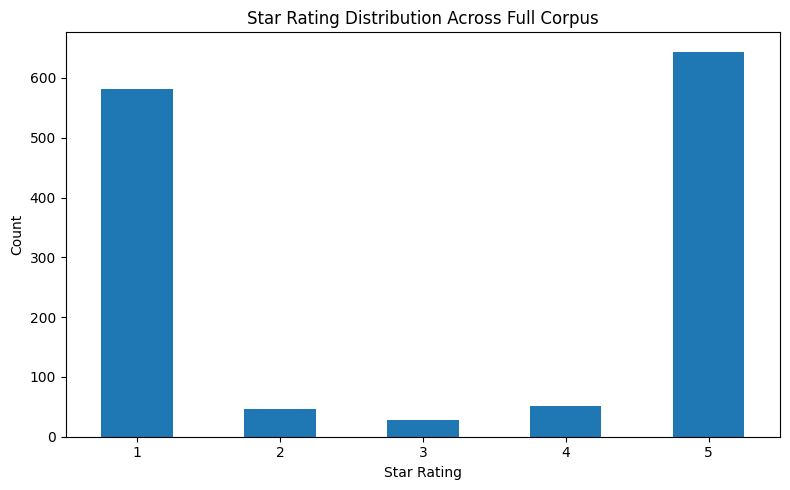

Saved: rating_distribution.png


In [11]:
# ============================================================
# CELL 5 — CORPUS OVERVIEW
# ============================================================

print("=== CORPUS OVERVIEW ===")

print("\nTotal reviews:", len(df))

print("\nReviews per brand:")
print(df["Brand"].value_counts())

print("\nReviews per category:")
print(df["Category"].value_counts())

print("\nRating distribution:")
print(df["Rating"].value_counts().sort_index())

# Review length
df["Review_Length"] = df["Text"].fillna("").str.split().str.len()

print("\nAverage review length by brand:")
print(df.groupby("Brand")["Review_Length"].mean().round(1))

print("\nOverall average review length:",
      round(df["Review_Length"].mean(), 1), "words")

# Rating distribution figure
plt.figure(figsize=(8, 5))

df["Rating"].value_counts().sort_index().plot(kind="bar")

plt.title("Star Rating Distribution Across Full Corpus")
plt.xlabel("Star Rating")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig("rating_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: rating_distribution.png")

In [12]:
# ============================================================
# CELL 6 — VADER SENTIMENT ANALYSIS
# ============================================================

analyzer = SentimentIntensityAnalyzer()

def get_vader_sentiment(text):

    scores = analyzer.polarity_scores(str(text))
    compound = scores["compound"]

    if compound >= 0.05:
        label = "Positive"

    elif compound <= -0.05:
        label = "Negative"

    else:
        label = "Neutral"

    return label, compound


df[["Vader_Label", "Vader_Score"]] = df["Text"].apply(
    lambda x: pd.Series(get_vader_sentiment(x))
)

print("=== OVERALL SENTIMENT DISTRIBUTION ===")

print(df["Vader_Label"].value_counts())

print("\nPercentages:")
print(
    (df["Vader_Label"].value_counts(normalize=True) * 100).round(1)
)

print("\n=== SENTIMENT BY BRAND ===")
print(pd.crosstab(df["Brand"], df["Vader_Label"]))

print("\n=== SENTIMENT BY CATEGORY ===")
print(pd.crosstab(df["Category"], df["Vader_Label"]))

print("\n=== AVERAGE VADER SCORE BY BRAND ===")
print(
    df.groupby("Brand")["Vader_Score"]
    .mean()
    .round(3)
    .sort_values(ascending=False)
)

=== OVERALL SENTIMENT DISTRIBUTION ===
Vader_Label
Positive    830
Negative    489
Neutral      33
Name: count, dtype: int64

Percentages:
Vader_Label
Positive    61.4
Negative    36.2
Neutral      2.4
Name: proportion, dtype: float64

=== SENTIMENT BY BRAND ===
Vader_Label       Negative  Neutral  Positive
Brand                                        
ASOS                   142        9        47
Boohoo                 113        3        72
Finisterre               5        4       163
Lucy & Yak               9        3       128
Missguided             145        6        46
Primark                 62        2        61
Rapanui                  8        1       145
Seasalt Cornwall         5        5       168

=== SENTIMENT BY CATEGORY ===
Vader_Label      Negative  Neutral  Positive
Category                                    
Ethical Fashion        27       13       604
Fast Fashion          462       20       226

=== AVERAGE VADER SCORE BY BRAND ===
Brand
Finisterre          0.

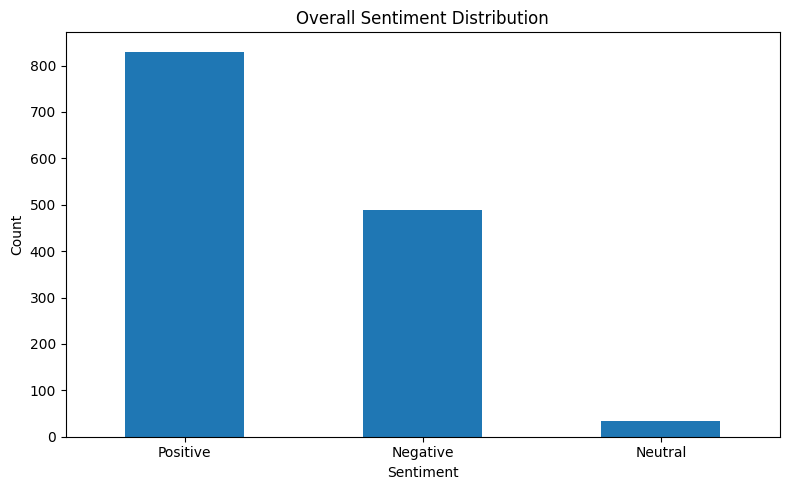

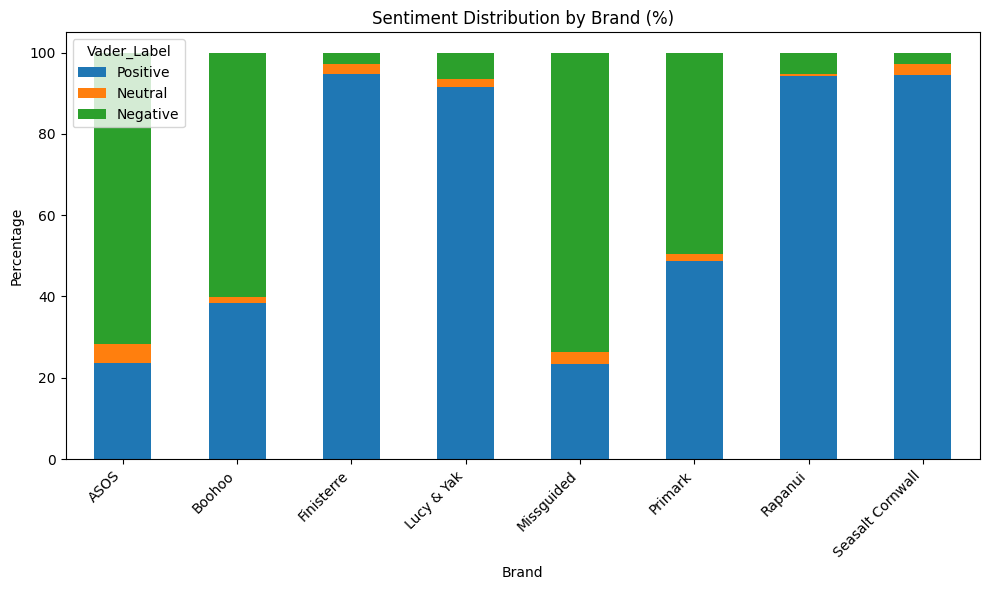

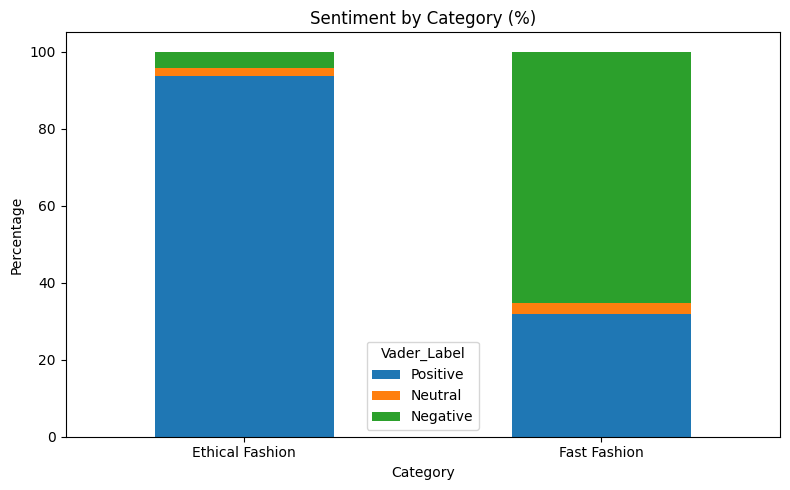

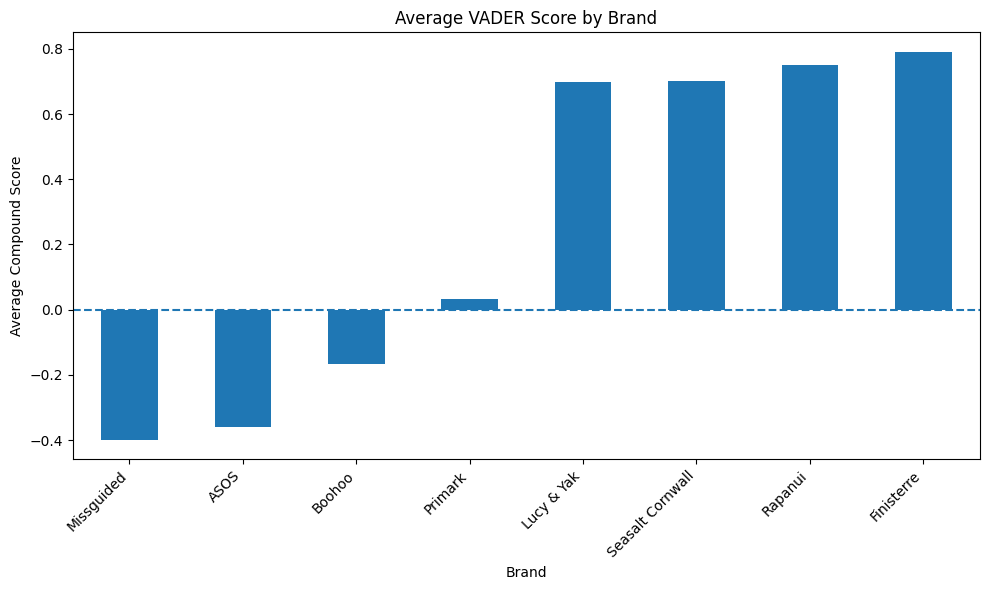

In [13]:
# ============================================================
# CELL 7 — VADER VISUALISATIONS
# ============================================================

# -------------------------------
# Overall sentiment
# -------------------------------

sentiment_counts = df["Vader_Label"].value_counts()

plt.figure(figsize=(8, 5))

sentiment_counts.plot(kind="bar")

plt.title("Overall Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig("overall_sentiment.png", dpi=300, bbox_inches="tight")
plt.show()


# -------------------------------
# Sentiment by brand
# -------------------------------

sentiment_brand = pd.crosstab(
    df["Brand"],
    df["Vader_Label"],
    normalize="index"
) * 100

cols = [
    c for c in ["Positive", "Neutral", "Negative"]
    if c in sentiment_brand.columns
]

sentiment_brand[cols].plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Sentiment Distribution by Brand (%)")
plt.xlabel("Brand")
plt.ylabel("Percentage")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig("sentiment_by_brand.png", dpi=300, bbox_inches="tight")
plt.show()


# -------------------------------
# Sentiment by category
# -------------------------------

sentiment_category = pd.crosstab(
    df["Category"],
    df["Vader_Label"],
    normalize="index"
) * 100

cols = [
    c for c in ["Positive", "Neutral", "Negative"]
    if c in sentiment_category.columns
]

sentiment_category[cols].plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.title("Sentiment by Category (%)")
plt.xlabel("Category")
plt.ylabel("Percentage")
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig("sentiment_by_category.png", dpi=300, bbox_inches="tight")
plt.show()


# -------------------------------
# Average VADER score by brand
# -------------------------------

avg_vader = (
    df.groupby("Brand")["Vader_Score"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10, 6))

avg_vader.plot(kind="bar")

plt.axhline(y=0, linestyle="--")

plt.title("Average VADER Score by Brand")
plt.xlabel("Brand")
plt.ylabel("Average Compound Score")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig("average_vader_by_brand.png", dpi=300, bbox_inches="tight")
plt.show()

=== VADER VALIDATION ===

Accuracy: 0.845 (84.5%)

Classification Report:
              precision    recall  f1-score   support

    Positive       0.81      0.97      0.88       696
     Neutral       0.00      0.00      0.00        28
    Negative       0.96      0.75      0.84       628

    accuracy                           0.85      1352
   macro avg       0.59      0.57      0.57      1352
weighted avg       0.86      0.85      0.84      1352



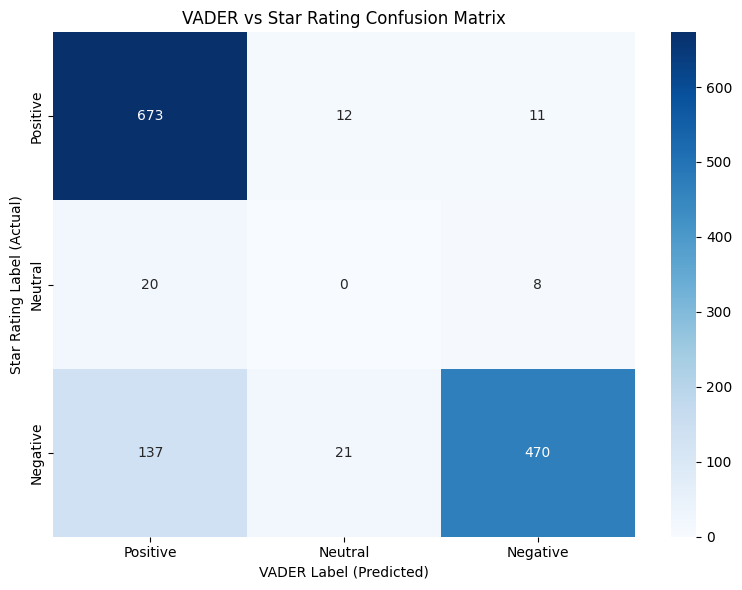


Correlation between VADER Score and Star Rating:
             Vader_Score  Rating
Vader_Score        1.000   0.803
Rating             0.803   1.000


In [14]:
# ============================================================
# CELL 8 — VADER VALIDATION AGAINST STAR RATINGS
# ============================================================

def rating_to_sentiment(rating):

    if rating >= 4:
        return "Positive"

    elif rating == 3:
        return "Neutral"

    else:
        return "Negative"


df["Rating_Label"] = df["Rating"].apply(rating_to_sentiment)

accuracy = accuracy_score(
    df["Rating_Label"],
    df["Vader_Label"]
)

print("=== VADER VALIDATION ===")

print(
    f"\nAccuracy: {accuracy:.3f} "
    f"({accuracy * 100:.1f}%)"
)

print("\nClassification Report:")

print(
    classification_report(
        df["Rating_Label"],
        df["Vader_Label"],
        labels=["Positive", "Neutral", "Negative"]
    )
)

cm = confusion_matrix(
    df["Rating_Label"],
    df["Vader_Label"],
    labels=["Positive", "Neutral", "Negative"]
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Positive", "Neutral", "Negative"],
    yticklabels=["Positive", "Neutral", "Negative"]
)

plt.title("VADER vs Star Rating Confusion Matrix")
plt.ylabel("Star Rating Label (Actual)")
plt.xlabel("VADER Label (Predicted)")

plt.tight_layout()
plt.savefig("vader_validation.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nCorrelation between VADER Score and Star Rating:")

print(
    df[["Vader_Score", "Rating"]]
    .corr()
    .round(3)
)

In [15]:
# ============================================================
# CELL 9 — CHI-SQUARE TEST AND CRAMÉR'S V
# ============================================================

contingency = pd.crosstab(
    df["Category"],
    df["Vader_Label"]
)

print("=== CONTINGENCY TABLE ===")
print(contingency)

chi2, p, dof, expected = chi2_contingency(contingency)


def cramers_v(contingency_table):

    chi2_value = chi2_contingency(contingency_table)[0]

    n = contingency_table.to_numpy().sum()

    r, k = contingency_table.shape

    return np.sqrt(
        chi2_value /
        (n * (min(r, k) - 1))
    )


v = cramers_v(contingency)

if v < 0.1:
    effect = "negligible"

elif v < 0.3:
    effect = "small"

elif v < 0.5:
    effect = "moderate"

else:
    effect = "large"


print("\n=== CHI-SQUARE RESULTS ===")

print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {p:.6f}")
print(f"Degrees of freedom: {dof}")
print(f"Cramér's V: {v:.4f}")
print(f"Effect size: {effect}")

=== CONTINGENCY TABLE ===
Vader_Label      Negative  Neutral  Positive
Category                                    
Ethical Fashion        27       13       604
Fast Fashion          462       20       226

=== CHI-SQUARE RESULTS ===
Chi-square statistic: 558.8201
P-value: 0.000000
Degrees of freedom: 2
Cramér's V: 0.6429
Effect size: large


In [16]:
# ============================================================
# CELL 10 — BERTOPIC MODEL
# ============================================================

print("Starting BERTopic model...")

umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

hdbscan_model = HDBSCAN(
    min_cluster_size=20,
    min_samples=10,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

embedding_model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    min_topic_size=20,
    nr_topics="auto",
    calculate_probabilities=False,
    verbose=True
)

docs = (
    df["Clean_Text"]
    .fillna("")
    .astype(str)
    .tolist()
)

# FIT ONCE ONLY
topics, probs = topic_model.fit_transform(docs)

df["Topic"] = topics

topic_info = topic_model.get_topic_info()

total_topics = len(
    topic_info[topic_info["Topic"] != -1]
)

outlier_count = int(
    (df["Topic"] == -1).sum()
)

outlier_pct = round(
    outlier_count / len(df) * 100,
    1
)

print("\n=== BERTOPIC RESULTS ===")

print("Total substantive topics:", total_topics)

print(
    f"Outlier documents: "
    f"{outlier_count} ({outlier_pct}%)"
)

display(topic_info)

Starting BERTopic model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

2026-08-23 06:39:34,050 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/43 [00:00<?, ?it/s]

2026-08-23 06:40:30,890 - BERTopic - Embedding - Completed ✓
2026-08-23 06:40:30,892 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-08-23 06:40:36,599 - BERTopic - Dimensionality - Completed ✓
2026-08-23 06:40:36,601 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-08-23 06:40:36,658 - BERTopic - Cluster - Completed ✓
2026-08-23 06:40:36,659 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-08-23 06:40:36,731 - BERTopic - Representation - Completed ✓
2026-08-23 06:40:36,732 - BERTopic - Topic reduction - Reducing number of topics
2026-08-23 06:40:36,747 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-08-23 06:40:36,810 - BERTopic - Representation - Completed ✓
2026-08-23 06:40:36,813 - BERTopic - Topic reduction - Reduced number of topics from 19 to 10



=== BERTOPIC RESULTS ===
Total substantive topics: 9
Outlier documents: 490 (36.2%)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,490,-1_item_customer_return_service,"[item, customer, return, service, order, refun...",[think even star generous absolute joke asos b...
1,0,432,0_return_refund_customer_item,"[return, refund, customer, item, order, servic...",[worst customer service ever received trying m...
2,1,204,1_quality_great_rapanui_clothes,"[quality, great, rapanui, clothes, good, love,...",[love company clothes great quality return qui...
3,2,48,2_jacket_finisterre_service_customer,"[jacket, finisterre, service, customer, coat, ...",[received quick helpful service finisterre tea...
4,3,40,3_service_customer_helpful_friendly,"[service, customer, helpful, friendly, thanks,...",[excellent customer service helpful efficient ...
5,4,36,4_delivery_easy_good_quality,"[delivery, easy, good, quality, packaging, pro...",[clear website use ordering easy email communi...
6,5,31,5_query_answered_kai_helpful,"[query, answered, kai, helpful, response, quic...","[quick response query thank, kai boohoowas hel..."
7,6,28,6_primark_staff_store_bag,"[primark, staff, store, bag, manager, customer...",[stevenage store place dump staff teenager sta...
8,7,23,7_primark_go_clothes_pajama,"[primark, go, clothes, pajama, buy, quality, s...",[absolutely love primark whenever go find im l...
9,8,20,8_star_zero_give_would,"[star, zero, give, would, could, get, money, d...",[could give company zero star would missguided...


In [17]:
# ============================================================
# CELL 11 — TOPIC KEYWORDS AND REPRESENTATIVE REVIEWS
# ============================================================

print("=== TOPIC DETAILS ===")

for row in topic_info.itertuples():

    if row.Topic == -1:
        continue

    words = topic_model.get_topic(row.Topic)

    keywords = [
        word[0]
        for word in words[:8]
    ]

    representative_docs = topic_model.get_representative_docs(
        row.Topic
    )

    print("\n--------------------------------------")

    print(
        f"Topic {row.Topic} "
        f"({row.Count} reviews)"
    )

    print(
        "Keywords:",
        ", ".join(keywords)
    )

    if representative_docs:

        print(
            "Representative review:",
            representative_docs[0][:200]
        )

=== TOPIC DETAILS ===

--------------------------------------
Topic 0 (432 reviews)
Keywords: return, refund, customer, item, order, service, asos, day
Representative review: worst customer service ever received trying make return tried make return several item system would let first said worked never received qr code tried said many item tried gave option return collected

--------------------------------------
Topic 1 (204 reviews)
Keywords: quality, great, rapanui, clothes, good, love, fit, clothing
Representative review: love company clothes great quality return quick easy would absolutely recommend

--------------------------------------
Topic 2 (48 reviews)
Keywords: jacket, finisterre, service, customer, coat, waterproof, size, bought
Representative review: received quick helpful service finisterre team really happy jacket bought brilliant thank

--------------------------------------
Topic 3 (40 reviews)
Keywords: service, customer, helpful, friendly, thanks, excellent, great, 

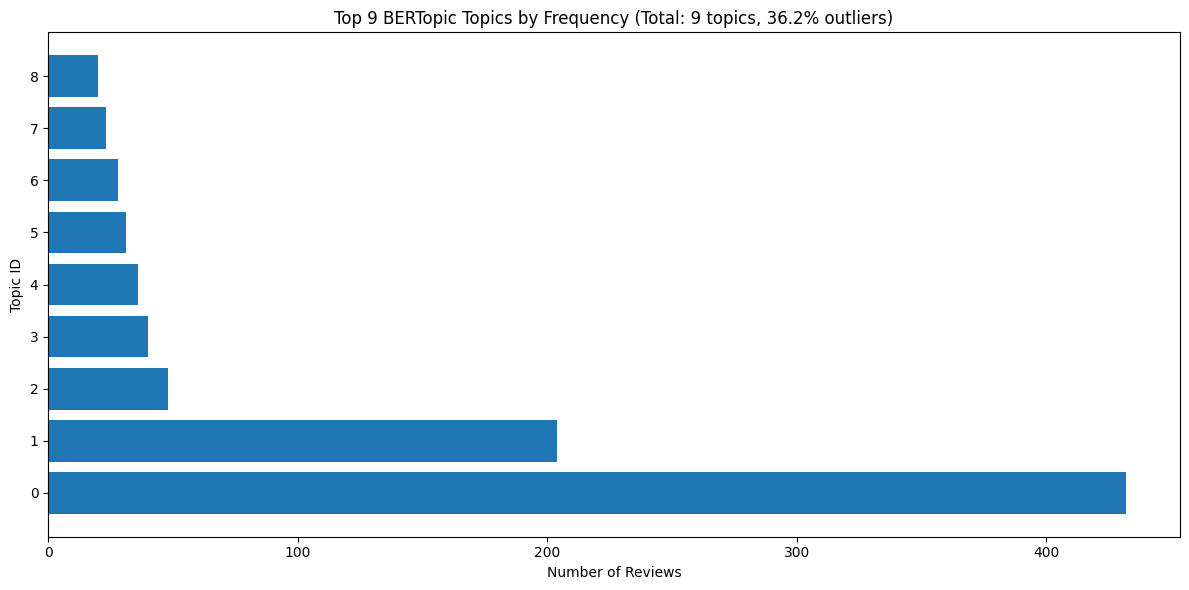

Saved: bertopic_topics.png


In [18]:
# ============================================================
# CELL 12 — BERTOPIC FREQUENCY FIGURE
# ============================================================

topic_info_filtered = (
    topic_info[
        topic_info["Topic"] != -1
    ]
    .head(10)
)

top_n = len(topic_info_filtered)

plt.figure(figsize=(12, 6))

plt.barh(
    topic_info_filtered["Topic"].astype(str),
    topic_info_filtered["Count"]
)

plt.title(
    f"Top {top_n} BERTopic Topics by Frequency "
    f"(Total: {total_topics} topics, "
    f"{outlier_pct}% outliers)"
)

plt.xlabel("Number of Reviews")
plt.ylabel("Topic ID")

plt.tight_layout()

plt.savefig(
    "bertopic_topics.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: bertopic_topics.png")

=== TOPIC × SENTIMENT COUNTS ===


Vader_Label,Negative,Neutral,Positive
Topic,,,
0,259,13,160
1,7,0,197
2,4,2,42
3,0,0,40
4,0,3,33
5,0,2,29
6,19,0,9
7,8,1,14
8,19,0,1



=== TOPIC × SENTIMENT PERCENTAGES ===


Vader_Label,Negative,Neutral,Positive
Topic,,,
0,60.0,3.0,37.0
1,3.4,0.0,96.6
2,8.3,4.2,87.5
3,0.0,0.0,100.0
4,0.0,8.3,91.7
5,0.0,6.5,93.5
6,67.9,0.0,32.1
7,34.8,4.3,60.9
8,95.0,0.0,5.0


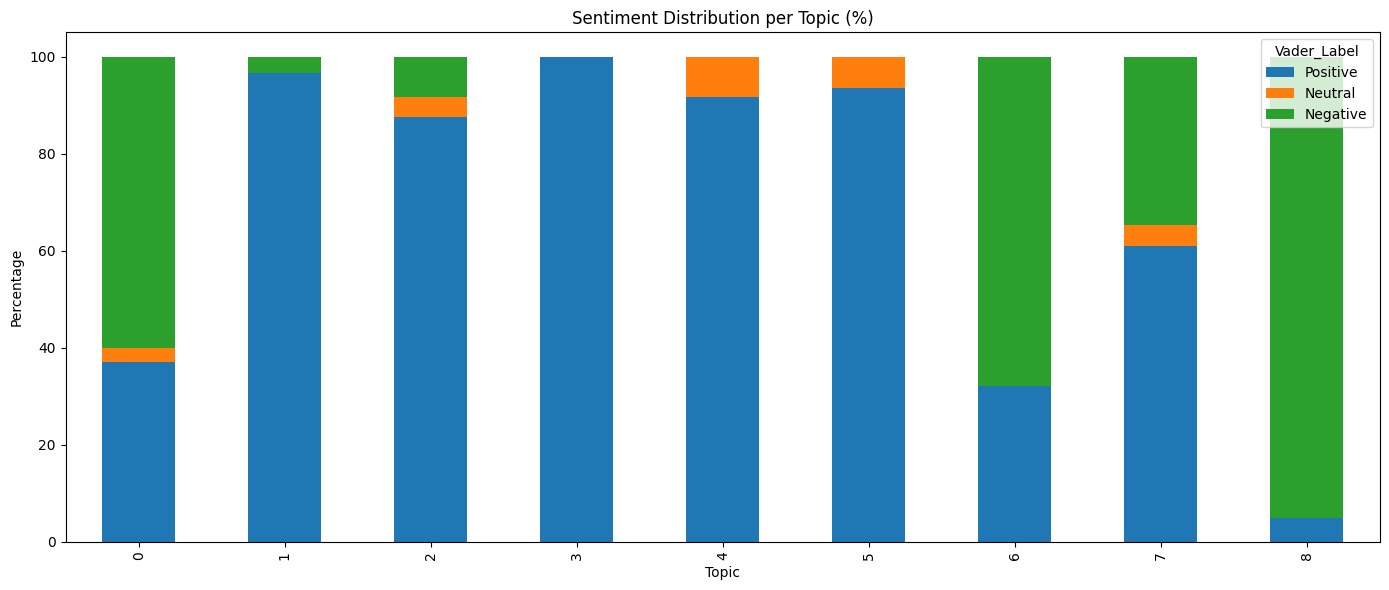

In [19]:
# ============================================================
# CELL 13 — TOPIC × SENTIMENT ANALYSIS
# ============================================================

topic_sentiment = pd.crosstab(
    df["Topic"],
    df["Vader_Label"]
)

print("=== TOPIC × SENTIMENT COUNTS ===")

display(
    topic_sentiment[
        topic_sentiment.index != -1
    ]
)


topic_sent_pct = pd.crosstab(
    df["Topic"],
    df["Vader_Label"],
    normalize="index"
) * 100

print("\n=== TOPIC × SENTIMENT PERCENTAGES ===")

display(
    topic_sent_pct[
        topic_sent_pct.index != -1
    ].round(1)
)


topic_sent_plot = topic_sent_pct[
    topic_sent_pct.index != -1
]

cols = [
    c for c in ["Positive", "Neutral", "Negative"]
    if c in topic_sent_plot.columns
]

topic_sent_plot[cols].plot(
    kind="bar",
    stacked=True,
    figsize=(14, 6)
)

plt.title("Sentiment Distribution per Topic (%)")
plt.xlabel("Topic")
plt.ylabel("Percentage")

plt.tight_layout()

plt.savefig(
    "topic_sentiment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [20]:
# ============================================================
# CELL 14 — BRAND × TOPIC CROSSTAB
# ============================================================

brand_topic = pd.crosstab(
    df["Brand"],
    df["Topic"]
)

print("=== BRAND × TOPIC CROSSTAB ===")

display(brand_topic)

# Save for checking Chapter 4 statements
brand_topic.to_csv(
    "brand_topic_crosstab.csv"
)

print("Saved: brand_topic_crosstab.csv")

=== BRAND × TOPIC CROSSTAB ===


Topic,-1,0,1,2,3,4,5,6,7,8
Brand,,,,,,,,,,
ASOS,62,125,1,0,1,3,0,0,0,6
Boohoo,97,75,0,2,0,0,11,0,0,3
Finisterre,71,29,7,40,15,1,9,0,0,0
Lucy & Yak,57,51,12,2,8,0,10,0,0,0
Missguided,61,123,0,2,0,0,0,0,0,11
Primark,41,20,9,0,3,1,0,28,23,0
Rapanui,42,2,97,2,7,3,1,0,0,0
Seasalt Cornwall,59,7,78,0,6,28,0,0,0,0


Saved: brand_topic_crosstab.csv


In [21]:
# ============================================================
# CELL 15 — CORRECTED SUSTAINABILITY TERM ANALYSIS
# ============================================================
#
# CORRECTION:
# 1. Uses word boundaries
# 2. Allows legitimate morphological variants
# 3. "eco" must appear as a standalone word
# 4. Prevents recommend, second, become, economy etc.
#    from being falsely counted as "eco"
#
# ============================================================

print("=== CORRECTED SUSTAINABILITY TERM FREQUENCY ===")

stem_terms = {

    "sustainab":
        r"\bsustainab\w*",

    "ethic":
        r"\bethic\w*",

    "eco":
        r"\beco\b",

    "organic":
        r"\borganic\w*",

    "recycl":
        r"\brecycl\w*",

    "greenwash":
        r"\bgreenwash\w*",

    "environment":
        r"\benvironment\w*",

    "carbon":
        r"\bcarbon\w*",

    "fair trade":
        r"\bfair\s+trade\b",

    "climate":
        r"\bclimate\w*",

    "renewable":
        r"\brenewable\w*",

    "conscious":
        r"\bconscious\w*",

    "vegan":
        r"\bvegan\w*"
}


text_lower = (
    df["Text"]
    .fillna("")
    .astype(str)
    .str.lower()
)


term_rows = []


for label, pattern in stem_terms.items():

    mask = text_lower.str.contains(
        pattern,
        regex=True,
        na=False
    )

    count = int(mask.sum())

    percentage = round(
        count / len(df) * 100,
        1
    )

    term_rows.append(
        [label, count, percentage]
    )

    print(
        f"{label}: "
        f"{count} reviews "
        f"({percentage}%)"
    )

=== CORRECTED SUSTAINABILITY TERM FREQUENCY ===
sustainab: 37 reviews (2.7%)
ethic: 43 reviews (3.2%)
eco: 10 reviews (0.7%)
organic: 16 reviews (1.2%)
recycl: 14 reviews (1.0%)
greenwash: 0 reviews (0.0%)
environment: 20 reviews (1.5%)
carbon: 0 reviews (0.0%)
fair trade: 1 reviews (0.1%)
climate: 2 reviews (0.1%)
renewable: 1 reviews (0.1%)
conscious: 4 reviews (0.3%)
vegan: 0 reviews (0.0%)


In [22]:
# ============================================================
# CELL 16 — CHECK "UNETHICAL" SEPARATELY
# ============================================================

unethical_mask = text_lower.str.contains(
    r"\bunethical\b",
    regex=True,
    na=False
)

unethical_count = int(
    unethical_mask.sum()
)

print(
    "'unethical' appears in:",
    unethical_count,
    "reviews"
)

if unethical_count > 0:

    print(
        "\nThese reviews should be interpreted separately "
        "because 'unethical' has the opposite meaning to 'ethical'."
    )

    display(
        df.loc[
            unethical_mask,
            ["Brand", "Text"]
        ]
    )

'unethical' appears in: 0 reviews


In [23]:
# ============================================================
# CELL 17 — CORRECTED SUSTAINABILITY TOTAL
# ============================================================

combined_pattern = "|".join(
    stem_terms.values()
)

any_sustainability_mask = text_lower.str.contains(
    combined_pattern,
    regex=True,
    na=False
)

total_with_any = int(
    any_sustainability_mask.sum()
)

total_pct = round(
    total_with_any / len(df) * 100,
    1
)

no_term_count = (
    len(df) - total_with_any
)

no_term_pct = round(
    no_term_count / len(df) * 100,
    1
)

print("=== CORRECTED RESULTS ===")

print(
    f"ANY sustainability term: "
    f"{total_with_any} reviews "
    f"({total_pct}%)"
)

print(
    f"NO sustainability term: "
    f"{no_term_count} reviews "
    f"({no_term_pct}%)"
)

=== CORRECTED RESULTS ===
ANY sustainability term: 103 reviews (7.6%)
NO sustainability term: 1249 reviews (92.4%)


In [24]:
# ============================================================
# CELL 18 — GENERATE CORRECTED TABLE 7
# ============================================================

term_frequency = pd.DataFrame(
    term_rows,
    columns=[
        "Term_or_Stem",
        "Reviews",
        "Percentage"
    ]
)

term_frequency.loc[
    len(term_frequency)
] = [
    "ANY Sustainability Term",
    total_with_any,
    total_pct
]

term_frequency.loc[
    len(term_frequency)
] = [
    "NO Sustainability Term",
    no_term_count,
    no_term_pct
]

print("=== CORRECTED TABLE 7 ===")

display(term_frequency)

term_frequency.to_csv(
    "sustainability_term_frequency_corrected.csv",
    index=False
)

print(
    "Saved: sustainability_term_frequency_corrected.csv"
)

=== CORRECTED TABLE 7 ===


,Term_or_Stem,Reviews,Percentage
0,sustainab,37,2.7
1,ethic,43,3.2
2,eco,10,0.7
3,organic,16,1.2
4,recycl,14,1.0
5,greenwash,0,0.0
6,environment,20,1.5
7,carbon,0,0.0
8,fair trade,1,0.1
9,climate,2,0.1


Saved: sustainability_term_frequency_corrected.csv


In [25]:
# ============================================================
# CELL 19 — ADD SUSTAINABILITY RESULTS TO DATASET
# ============================================================

def find_sustainability_terms(text):

    text = str(text).lower()

    matches = []

    for label, pattern in stem_terms.items():

        if re.search(pattern, text):
            matches.append(label)

    return matches


df["Sustainability_Terms_Matched"] = (
    df["Text"]
    .fillna("")
    .apply(
        lambda x: "|".join(
            find_sustainability_terms(x)
        )
    )
)

df["Has_Sustainability_Term"] = (
    df["Sustainability_Terms_Matched"] != ""
)

df["Has_Unethical_Term"] = unethical_mask


display(
    df[
        [
            "Brand",
            "Text",
            "Sustainability_Terms_Matched",
            "Has_Sustainability_Term",
            "Has_Unethical_Term"
        ]
    ].head(10)
)

,Brand,Text,Sustainability_Terms_Matched,Has_Sustainability_Term,Has_Unethical_Term
0,Seasalt Cornwall,Easy ordering process and a very quick deliver...,,False,False
1,Seasalt Cornwall,Website easy to navigate. I ordered a dress fo...,,False,False
2,Seasalt Cornwall,"Easy to order, came within a few days, very pl...",,False,False
3,ASOS,Don’t bother ordering stuff in the summer or h...,,False,False
4,Lucy & Yak,"I absolutely love your brand, and after finall...",,False,False
5,Seasalt Cornwall,"Quick, efficient and article just as described...",,False,False
6,Seasalt Cornwall,"Good quality, good sizing and lovely styles",,False,False
7,Boohoo,1. The seller is breaking the law by not adher...,,False,False
8,Seasalt Cornwall,"I liked the dresses, that fitted well. Service...",,False,False
9,Seasalt Cornwall,"Lovely vibrant colours, great to wear lightwei...",,False,False


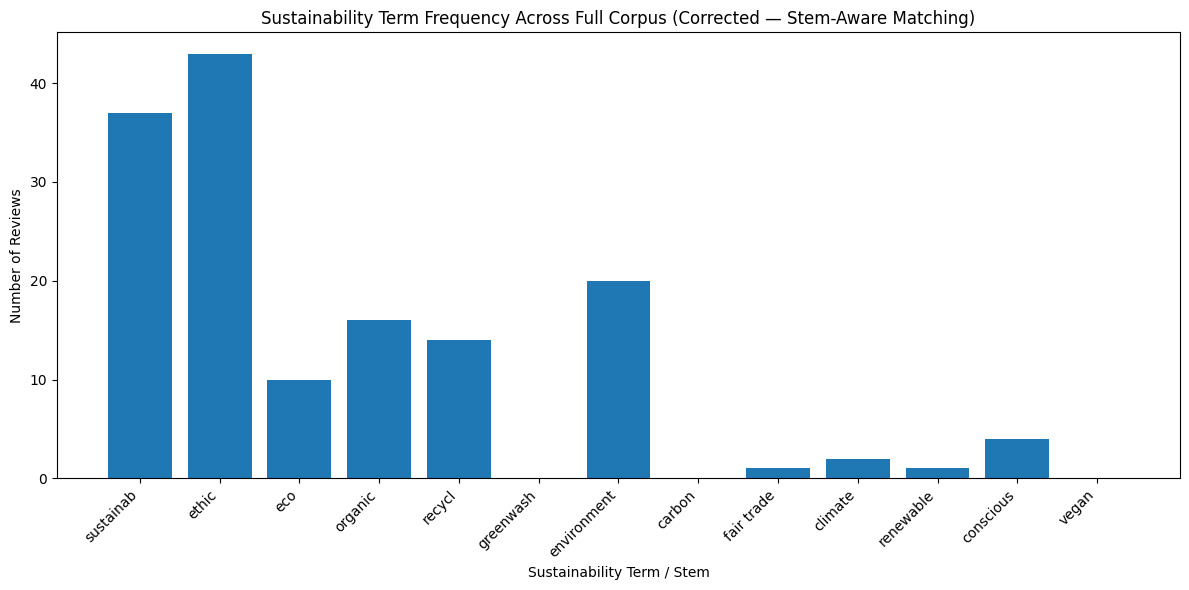

Saved: sustainability_terms_corrected.png


In [26]:
# ============================================================
# CELL 20 — CORRECTED SUSTAINABILITY FIGURE 9
# ============================================================

plot_data = term_frequency.iloc[:-2]

plt.figure(figsize=(12, 6))

plt.bar(
    plot_data["Term_or_Stem"],
    plot_data["Reviews"]
)

plt.title(
    "Sustainability Term Frequency Across Full Corpus "
    "(Corrected — Stem-Aware Matching)"
)

plt.xlabel("Sustainability Term / Stem")
plt.ylabel("Number of Reviews")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.savefig(
    "sustainability_terms_corrected.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved: sustainability_terms_corrected.png"
)

In [27]:
# ============================================================
# CELL 21 — BRAND REVIEW DATE RANGE ANALYSIS
# ============================================================

df["Date_Parsed"] = pd.to_datetime(
    df["Date"],
    errors="coerce",
    utc=True
)

date_ranges = (
    df.groupby(
        "Brand",
        as_index=False
    )
    .agg(
        Reviews=("Text", "size"),
        Start_Date=("Date_Parsed", "min"),
        End_Date=("Date_Parsed", "max")
    )
)

date_ranges["Coverage_Days"] = (
    date_ranges["End_Date"] -
    date_ranges["Start_Date"]
).dt.days + 1


date_ranges["Start_Date"] = (
    date_ranges["Start_Date"]
    .dt.strftime("%Y-%m-%d")
)

date_ranges["End_Date"] = (
    date_ranges["End_Date"]
    .dt.strftime("%Y-%m-%d")
)


print("=== REVIEW DATE RANGE BY BRAND ===")

display(date_ranges)


date_ranges.to_csv(
    "brand_review_date_ranges.csv",
    index=False
)

print(
    "Saved: brand_review_date_ranges.csv"
)

=== REVIEW DATE RANGE BY BRAND ===


,Brand,Reviews,Start_Date,End_Date,Coverage_Days
0,ASOS,198,2026-06-08,2026-07-07,29
1,Boohoo,188,2026-05-29,2026-07-07,39
2,Finisterre,172,2025-05-02,2026-07-01,425
3,Lucy & Yak,140,2025-07-16,2026-07-07,356
4,Missguided,197,2025-08-09,2026-07-06,332
5,Primark,125,2018-11-12,2026-06-28,2786
6,Rapanui,154,2026-03-12,2026-07-06,116
7,Seasalt Cornwall,178,2026-07-05,2026-07-07,3


Saved: brand_review_date_ranges.csv


In [28]:
# ============================================================
# CELL 22 — SAVE ALL CORRECTED RESULTS
# ============================================================

df.to_csv(
    "final_results_corrected.csv",
    index=False
)

topic_info.to_csv(
    "topic_info.csv",
    index=False
)

brand_topic.to_csv(
    "brand_topic_crosstab.csv"
)

topic_sent_pct.to_csv(
    "topic_sentiment_percent.csv"
)

term_frequency.to_csv(
    "sustainability_term_frequency_corrected.csv",
    index=False
)

date_ranges.to_csv(
    "brand_review_date_ranges.csv",
    index=False
)

print("All corrected analysis files saved successfully.")

All corrected analysis files saved successfully.


In [29]:
# ============================================================
# CELL 23 — FINAL RESULTS CHECK
# ============================================================

print("==============================================")
print("FINAL ANALYSIS RESULTS")
print("==============================================")

print(
    f"\nTotal reviews: "
    f"{len(df)}"
)

print(
    f"\nBERTopic substantive topics: "
    f"{total_topics}"
)

print(
    f"BERTopic outliers: "
    f"{outlier_count} "
    f"({outlier_pct}%)"
)

print(
    f"\nVADER accuracy: "
    f"{accuracy * 100:.1f}%"
)

print(
    f"\nChi-square: "
    f"{chi2:.2f}"
)

print(
    f"P-value: "
    f"{p:.6f}"
)

print(
    f"Cramér's V: "
    f"{v:.3f}"
)

print(
    f"\nANY sustainability term: "
    f"{total_with_any} "
    f"({total_pct}%)"
)

print(
    f"NO sustainability term: "
    f"{no_term_count} "
    f"({no_term_pct}%)"
)

print(
    f"'Unethical' reviews: "
    f"{unethical_count}"
)

print("\n==============================================")

FINAL ANALYSIS RESULTS

Total reviews: 1352

BERTopic substantive topics: 9
BERTopic outliers: 490 (36.2%)

VADER accuracy: 84.5%

Chi-square: 558.82
P-value: 0.000000
Cramér's V: 0.643

ANY sustainability term: 103 (7.6%)
NO sustainability term: 1249 (92.4%)
'Unethical' reviews: 0



In [30]:
# ============================================================
# CELL 24 — DOWNLOAD CORRECTED OUTPUT FILES
# ============================================================

from google.colab import files

files.download(
    "final_results_corrected.csv"
)

files.download(
    "sustainability_term_frequency_corrected.csv"
)

files.download(
    "brand_review_date_ranges.csv"
)

files.download(
    "brand_topic_crosstab.csv"
)

files.download(
    "topic_sentiment_percent.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [31]:
# ============================================================
# CELL 25 — SAVE AND DOWNLOAD ALL GENERATED FIGURES
# ============================================================

import os
import glob
import shutil
from google.colab import files

# Create folder for all figures
figure_folder = "All_Generated_Figures"

os.makedirs(
    figure_folder,
    exist_ok=True
)

# Find all generated PNG figures
figure_files = glob.glob("*.png")

print("=== FIGURES FOUND ===")

for figure in figure_files:

    print(figure)

    shutil.copy(
        figure,
        figure_folder
    )

# Create ZIP file
zip_file = shutil.make_archive(
    "All_Generated_Figures",
    "zip",
    figure_folder
)

print("\n======================================")
print(f"Total figures saved: {len(figure_files)}")
print("ZIP created: All_Generated_Figures.zip")
print("======================================")

# Download ZIP
files.download(
    "All_Generated_Figures.zip"
)

=== FIGURES FOUND ===
rating_distribution.png
sustainability_terms_corrected.png
vader_validation.png
vader_results.png
average_vader_by_brand.png
topic_sentiment.png
bertopic_topics.png
overall_sentiment.png
sentiment_by_category.png
sentiment_by_brand.png

Total figures saved: 10
ZIP created: All_Generated_Figures.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>